# Customer Churn Classification


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


## 1. Load Customer data

In [6]:
file_path = "customer_churn_classification.xlsx"
# See available sheets
excel_file = pd.ExcelFile(file_path)
print("Available sheets:")
print(excel_file.sheet_names)
df = pd.read_excel(file_path, sheet_name="Customer data")
display(df.head())
print("Shape:",df.shape)
y=df["churned"]
X=df.drop(columns=["churned","customer_id"])
X=pd.get_dummies(X,drop_first=True)
print("X shape:",X.shape)
display(y.value_counts().sort_index())


Available sheets:
['Customer data', 'Data dictionary']


,customer_id,age_years,tenure_months,monthly_fee_inr,weekly_usage_hours,support_tickets_6m,late_payments_6m,discount_percent,auto_pay,satisfaction_score,competitor_offer,churned
0,C0001,39,50,800,11.5,3,1,20,1,9,1,0
1,C0002,58,20,1100,16.6,0,0,0,0,9,1,0
2,C0003,43,9,1350,14.6,3,0,0,1,7,0,0
3,C0004,42,40,850,13.5,6,1,5,1,5,0,1
4,C0005,26,44,800,11.8,5,3,5,0,4,0,1


Shape: (500, 12)
X shape: (500, 10)


churned
0    360
1    140
Name: count, dtype: int64

## 2. Stratified 80/20 split

In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,stratify=y,random_state=42)
print("Training size:",len(X_train)," Test size:",len(X_test))
print("\nCanceled in training:"); print(y_train.value_counts().sort_index())
print("\nCanceled in test:"); print(y_test.value_counts().sort_index())


Training size: 400  Test size: 100

Canceled in training:
churned
0    288
1    112
Name: count, dtype: int64

Canceled in test:
churned
0    72
1    28
Name: count, dtype: int64


## 3–5. Train five models and report metrics

In [8]:
models={
 "KNN":Pipeline([("scaler",StandardScaler()),("model",KNeighborsClassifier(n_neighbors=5))]),
 "Gaussian Naive Bayes":GaussianNB(),
 "Decision Tree":DecisionTreeClassifier(random_state=42,max_depth=5),
 "Random Forest":RandomForestClassifier(n_estimators=100,random_state=42),
 "Logistic Regression":Pipeline([("scaler",StandardScaler()),("model",LogisticRegression(max_iter=1000,random_state=42))])
}
results=[]; predictions={}
for name,model in models.items():
    model.fit(X_train,y_train); pred=model.predict(X_test); predictions[name]=pred
    results.append({"Model":name,"Accuracy":accuracy_score(y_test,pred),"Precision":precision_score(y_test,pred,zero_division=0),"Recall":recall_score(y_test,pred,zero_division=0),"F1-score":f1_score(y_test,pred,zero_division=0)})
results_df=pd.DataFrame(results); display(results_df.round(4))


,Model,Accuracy,Precision,Recall,F1-score
0,KNN,0.75,0.5652,0.4643,0.5098
1,Gaussian Naive Bayes,0.78,0.6000,0.6429,0.6207
2,Decision Tree,0.76,0.5833,0.5000,0.5385
3,Random Forest,0.86,0.7500,0.7500,0.7500
4,Logistic Regression,0.82,0.6562,0.7500,0.7000


In [9]:
for name,pred in predictions.items():
    print("\n"+"="*50+"\n"+name)
    print("Confusion Matrix:\n",confusion_matrix(y_test,pred))
    print("\n",classification_report(y_test,pred,zero_division=0))



KNN
Confusion Matrix:
 [[62 10]
 [15 13]]

               precision    recall  f1-score   support

           0       0.81      0.86      0.83        72
           1       0.57      0.46      0.51        28

    accuracy                           0.75       100
   macro avg       0.69      0.66      0.67       100
weighted avg       0.74      0.75      0.74       100


Gaussian Naive Bayes
Confusion Matrix:
 [[60 12]
 [10 18]]

               precision    recall  f1-score   support

           0       0.86      0.83      0.85        72
           1       0.60      0.64      0.62        28

    accuracy                           0.78       100
   macro avg       0.73      0.74      0.73       100
weighted avg       0.79      0.78      0.78       100


Decision Tree
Confusion Matrix:
 [[62 10]
 [14 14]]

               precision    recall  f1-score   support

           0       0.82      0.86      0.84        72
           1       0.58      0.50      0.54        28

    accuracy        

## 6. Compare models

In [10]:
comparison=results_df.copy()
comparison["False_Alarms"]=[confusion_matrix(y_test,predictions[r["Model"]]).ravel()[1] for _,r in comparison.iterrows()]
display(comparison.round(4))
print("Most customers who cancel caught (highest recall):",comparison.loc[comparison.Recall.idxmax(),"Model"])
print("Fewest false alarms:",comparison.loc[comparison.False_Alarms.idxmin(),"Model"])


,Model,Accuracy,Precision,Recall,F1-score,False_Alarms
0,KNN,0.75,0.5652,0.4643,0.5098,10
1,Gaussian Naive Bayes,0.78,0.6000,0.6429,0.6207,12
2,Decision Tree,0.76,0.5833,0.5000,0.5385,10
3,Random Forest,0.86,0.7500,0.7500,0.7500,7
4,Logistic Regression,0.82,0.6562,0.7500,0.7000,11


Most customers who cancel caught (highest recall): Random Forest
Fewest false alarms: Random Forest


## 7. Inspect learned model information

KNN K = 5


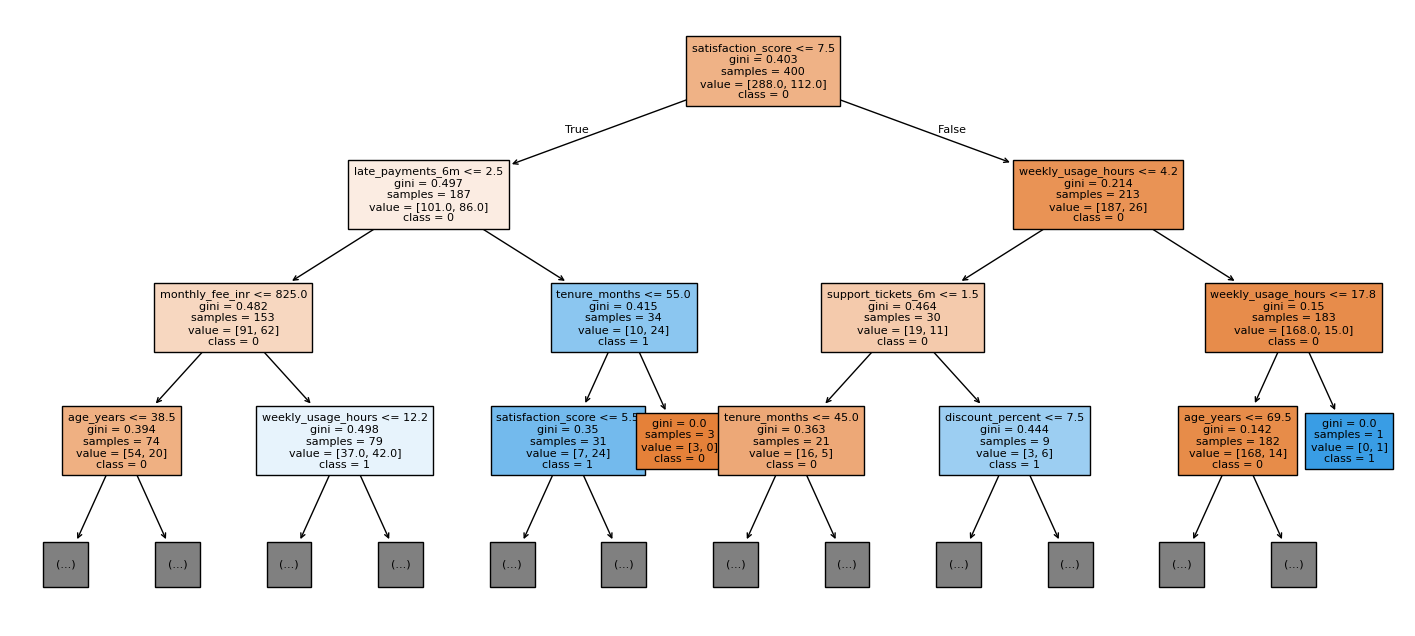

In [11]:
print("KNN K =",models["KNN"].named_steps["model"].n_neighbors)
tree=models["Decision Tree"]; plt.figure(figsize=(18,8)); plot_tree(tree,feature_names=X.columns,class_names=[str(c) for c in sorted(y.unique())],filled=True,max_depth=3,fontsize=8); plt.show()


In [12]:
rf=models["Random Forest"]
rf_importance=pd.DataFrame({"Feature":X.columns,"Importance":rf.feature_importances_}).sort_values("Importance",ascending=False)
display(rf_importance.head(15))


,Feature,Importance
3,weekly_usage_hours,0.185862
8,satisfaction_score,0.155158
1,tenure_months,0.126848
2,monthly_fee_inr,0.117922
0,age_years,0.111010
4,support_tickets_6m,0.101524
5,late_payments_6m,0.086130
6,discount_percent,0.054207
9,competitor_offer,0.039493
7,auto_pay,0.021847


In [13]:
lr=models["Logistic Regression"]
lr_coefficients=pd.DataFrame({"Feature":X.columns,"Coefficient":lr.named_steps["model"].coef_[0]})
lr_coefficients["Absolute_Coefficient"]=lr_coefficients["Coefficient"].abs()
display(lr_coefficients.sort_values("Absolute_Coefficient",ascending=False).head(15))


,Feature,Coefficient,Absolute_Coefficient
3,weekly_usage_hours,-0.779512,0.779512
4,support_tickets_6m,0.753621,0.753621
5,late_payments_6m,0.702986,0.702986
9,competitor_offer,0.665575,0.665575
2,monthly_fee_inr,0.546110,0.546110
8,satisfaction_score,-0.522834,0.522834
1,tenure_months,-0.518022,0.518022
7,auto_pay,-0.333217,0.333217
0,age_years,0.144534,0.144534
6,discount_percent,-0.039146,0.039146


## 8. Recommendation
For a retention campaign, prioritize recall when the goal is to catch as many customers who may cancel as possible. If false alarms are costly, consider precision and false positives as well. The final model should be selected from the evaluation results above rather than accuracy alone.